Проект: Оценка калорийности блюд (Multimodal DL)

Анализ датасета для удобства вынесен в отдельный файл - daaset_analize.ipnyb - там же отрисовка вводных данных
Применение модели в файл SPR_4_FIN.ipnyb
Класс датасета и модели в соответствующих класса в папке src
Config - в корне 


Датасет: 
- применен стандартный набор аугуменций и стандартизаций из урока.
- отдельно заранее посчитана калорийность блюд с 1 ингридиентов чтобы если: 
	блюдо из 1 ингридиента - то предсказывать калорийность точно
	блюдо из известных ингридиентов - брать калорийность так как будто пропорции блюд равны, что не является оптимальным. То есть по логике модель должна сама выделять пропорции и учиться,
	и такая модель лежит в папке MODEL__WORK - но она на 10 эпохах показал результат около 51 MAE на блюдо, что хуже, но вероятно на большем количестве эпох такая модель должна работать лучше
	, но ввиду ограниченности ресурсов и времени решил как основную приложить текущую модель - как более надежную
- для ингридиентов калорийность которых не известна - берется средня калорийность по группе продуктов взятая из интернета. Все это делается в файле dataset в функции avg_ingr_cal
- важным аспектом явлется то, что в датасете выделяется как таргет калорийность на 100 г продукта и далее уже модель учится прогнозировать калорийность на 100г , а для оченки точности
калорийность на 100г умножается на массу


Модель сама по себе мультимодальная, то есть в зависомости от типа по очереди применяетсяс concat/ умножение эмб/ кросс- платформенное внимание 


Общий вывод: при наличии технич ресурсов локально (CUDA) и времени - оптимально использовать "справочную модель" из папки MODEL_1_WORK - поскольку она сама учится всему, но учитывает для продуктов
из 1 блюда - точную калорийность. Но для этой модели явно нужно больше эпох и ее нужно тестировать с разными аугуменациями, что не возможно локально. Дополнительно у меня модель кернел 
просто падал с ошибкой коотрую лог обрезал - то есть ее нельзя было выявить, и на дебаге - тоже просто падение, поэтому многи правки вносились методом обычных ручных проверок на малой выборке. 
Тем не менее приложенная основная модель, тестирование которой в файле SPR_4_FIN.ipnyb - на полной выборке показала MAE на блюдо < 50

В целом конкатенация на 15 эпохаха показала более стабильно обучение и снижение ошибки от эпохе к эпохе. Перемножение явно хуже, а кросс-модальное внимание иногда и показывает лучшие характеристики, но быстрее переобучается (мин МАЕ достигается раньше и потом даже растет) и мнее стабильна. Но вероятно на количестве ЭПОХ> 100 данные могу быть другие (в зависимости от настроек аугуменации и прочей пред обработки)

In [ ]:
# train_main_multimodal.py

from pathlib import Path
import sys
# ------------------------- Путь до src -------------------------
project_root = Path.cwd()
src_dir = project_root / "src"
sys.path.append(str(src_dir))

# ------------------------- Импорты -------------------------
import importlib
import torch
import torch.nn as nn
import pandas as pd
import dataset 
import model  # <-- сначала импортируем
importlib.reload(dataset)  # перезагрузка, если нужно
importlib.reload(model)    # теперь можно перезагружать
from dataset import MultimodalDataset, avg_ingr_cal, get_transforms, collate_fn
from torch.utils.data import DataLoader
from functools import partial
from tqdm import tqdm
import albumentations as A
from albumentations.pytorch import ToTensorV2
import numpy as np

import timm

from model import MultimodalModel
import Config          # импортируем модуль целиком
importlib.reload(Config)  # теперь перезагружаем модуль
from Config import Config  # достаем класс после перезагрузки

from dataset import GROUP2ID


from model import MultimodalModel


print("Импорты прошли успешно!")
print("Torch version:", torch.__version__)

# ------------------------- TRAIN FUNCTION -------------------------
def train_model(fusion_type="concat"):
    print(f"\n=== TRAINING MODEL: {fusion_type} ===")
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"device : {device}")

    # ===== LOAD DATA =====
    df_all = pd.read_csv(Config.DATA_CSV)
    # df_all = pd.read_csv(Config.DATA_CSV, nrows=20)
    df_train = df_all[df_all["split"] == "train"].reset_index(drop=True)
    df_test  = df_all[df_all["split"] == "test"].reset_index(drop=True)

    # ===== INGREDIENT CAL DICT =====
    single = df_train[df_train["ingredients"].str.count(";") == 0].copy()
    single["cal_per_g"] = single["total_calories"] / single["total_mass"]
    ingr_cal = {r["ingredients"]: r["cal_per_g"] for _, r in single.iterrows()}

    for df in [df_train, df_test]:
        df["avg_ingr_cal"] = df["ingredients"].apply(lambda x: avg_ingr_cal(x, ingr_cal))
        df["cal_per_100g"] = df["total_calories"] / df["total_mass"] * 100

    # ===== TRANSFORMS =====
    train_tfm = get_transforms(Config, ds_type="train")
    test_tfm  = get_transforms(Config, ds_type="test")

    # ===== DATASETS & LOADERS =====
    train_ds = MultimodalDataset(df_train, train_tfm)
    test_ds  = MultimodalDataset(df_test, test_tfm)

    train_loader = DataLoader(
        train_ds,
        batch_size=Config.BATCH_SIZE,
        shuffle=True,
        collate_fn=partial(collate_fn, tokenizer=train_ds.tokenizer)
    )

    test_loader = DataLoader(
        test_ds,
        batch_size=Config.BATCH_SIZE,
        shuffle=False,
        collate_fn=partial(collate_fn, tokenizer=test_ds.tokenizer)
    )

    # ===== MODEL, LOSS, OPTIMIZER =====
    model = MultimodalModel(fusion_type=fusion_type).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=Config.HEAD_LR)
    loss_fn = nn.L1Loss()

    best_mae_100g = float("inf")
    best_epoch_100g = -1

    best_mae_dish = float("inf")
    best_epoch_dish = -1

    # ===== TRAIN LOOP =====
    test_predictions = []

    for e in range(Config.EPOCHS):
        model.train()
        train_mae_100g = 0.0
        train_mae_dish = 0.0

        for b in tqdm(train_loader, desc=f"Epoch {e+1} [Train]"):
            opt.zero_grad()

            preds = model(
                b["input_ids"].to(device),
                b["attention_mask"].to(device),
                b["image"].to(device),
                b["avg_cal"].to(device),
                b["group"].to(device)
            )

            labels = b["label"].to(device)
            mass_100g = b["mass"].to(device) / 100.0

            loss = loss_fn(preds, labels)
            loss.backward()
            opt.step()

            # MAE per 100g
            train_mae_100g += torch.mean(torch.abs(preds - labels)).item()
            # MAE per dish
            train_mae_dish += (torch.abs(preds - labels) * mass_100g).mean().item()

        train_mae_100g /= len(train_loader)
        train_mae_dish /= len(train_loader)

        # ---------- TEST ----------
        model.eval()
        test_mae_100g = 0.0
        test_mae_dish = 0.0

        with torch.no_grad():
            for b in test_loader:
                preds = model(
                    b["input_ids"].to(device),
                    b["attention_mask"].to(device),
                    b["image"].to(device),
                    b["avg_cal"].to(device),
                    b["group"].to(device)
                )

                labels = b["label"].to(device)
                mass_100g = b["mass"].to(device) / 100.0
                abs_err_100g = torch.abs(preds - labels)
                abs_err_dish = abs_err_100g * mass_100g


                test_mae_100g += torch.mean(torch.abs(preds - labels)).item()
                test_mae_dish += (torch.abs(preds - labels) * mass_100g).mean().item()

                for i in range(len(preds)):
                    test_predictions.append({
                        "dish_id": b["dish_id"][i],
                        "ingredients": b["text"][i],
                        "true_100g": labels[i].item(),
                        "pred_100g": preds[i].item(),
                        "err_100g": abs_err_100g[i].item(),
                        "true_dish": (labels[i] * mass_100g[i]).item(),
                        "pred_dish": (preds[i] * mass_100g[i]).item(),
                        "err_dish": abs_err_dish[i].item(),
                        "mass": b["mass"][i].item()
                    })

        test_mae_100g /= len(test_loader)
        test_mae_dish /= len(test_loader)

        if test_mae_100g < best_mae_100g:
            best_mae_100g = test_mae_100g
            best_epoch_100g = e + 1

        if test_mae_dish < best_mae_dish:
            best_mae_dish = test_mae_dish
            best_epoch_dish = e + 1

        print(
            f"Epoch {e+1} | "
            f"Train MAE: {train_mae_100g:.1f} kcal/100g, {train_mae_dish:.1f} kcal/dish | "
            f"Test MAE: {test_mae_100g:.1f} kcal/100g, {test_mae_dish:.1f} kcal/dish"
        )
        
    print(f"\nBest results for fusion='{fusion_type}':")
    print(f"MAE per 100g: {best_mae_100g:.1f} kcal at epoch {best_epoch_100g}")
    print(f"MAE dish: {best_mae_dish:.1f} kcal at epoch {best_epoch_dish}")

    pred_df = pd.DataFrame(test_predictions)
    return pred_df

# ------------------------- MAIN -------------------------
if __name__ == "__main__":
    all_results = {}

    for fusion in ["concat", "cross_attention"]:
        pred_df = train_model(fusion_type=fusion)
        all_results[fusion] = pred_df



Импорты прошли успешно!
Torch version: 2.7.1+cu126

=== TRAINING MODEL: concat ===
device : cuda


Epoch 1 [Train]:   1%|          | 2/173 [00:01<02:14,  1.27it/s]

Вывод 5 худших и лучших

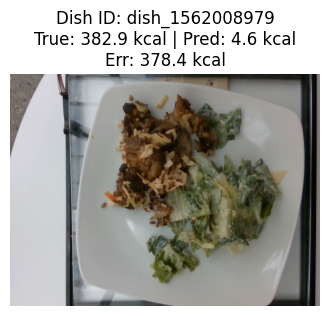

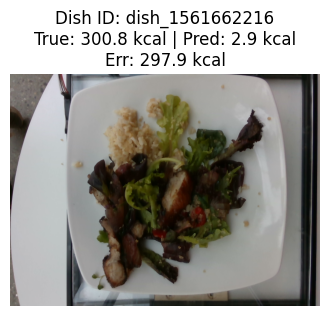

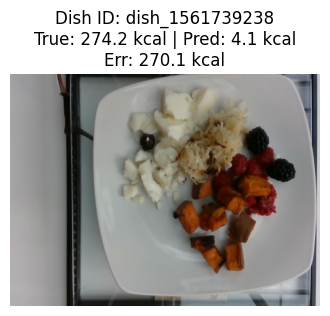

In [4]:
df = all_results["concat"]
df_unique = (  #убираю дубликаты так как на тесте для скорости использовал по 10 строк из дф - там одни и те же 
    df.sort_values("err_dish", ascending=False)
      .drop_duplicates(subset="dish_id", keep="first")
)

worst = df_unique.sort_values("err_dish", ascending=False).head(5)
best  = df_unique.sort_values("err_dish", ascending=True).head(5)

worst[[
    "dish_id",
    "ingredients",
    "true_dish",
    "pred_dish",
    "err_dish",
    "mass"
]]

best[[
    "dish_id",
    "ingredients",
    "true_dish",
    "pred_dish",
    "err_dish",
    "mass"
]]

from PIL import Image
import matplotlib.pyplot as plt

def show_dish(row):
    img_path = f"{Config.IMAGE_ROOT}/{row['dish_id']}/rgb.png"
    img = Image.open(img_path)

    plt.figure(figsize=(4,4))
    plt.imshow(img)
    plt.axis("off")
    plt.title(
        f"Dish ID: {row['dish_id']}\n"
        f"True: {row['true_dish']:.1f} kcal | "
        f"Pred: {row['pred_dish']:.1f} kcal\n"
        f"Err: {row['err_dish']:.1f} kcal"
    )
    plt.show()



for _, r in worst.iterrows():
    show_dish(r)


5 лучших

=== BEST 5 ===


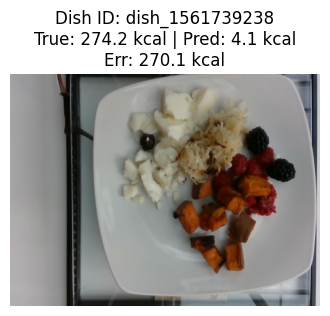

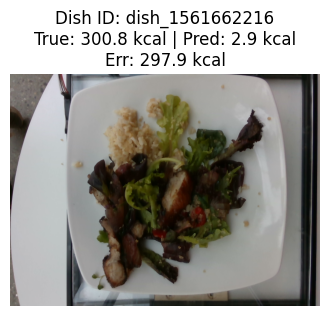

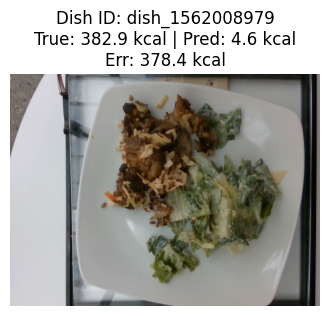

In [5]:
print("=== BEST 5 ===")
for _, r in best.iterrows():
    show_dish(r)

In [6]:
print("done")

done
